# Inflation data in China – Time series
## 1. You are given a time series containing inflation data in China (cpicyn_m_m.csv).
You are given a time series containing inflation data in China (cpicyn_m_m.csv).

**a.** Do not use the last five data points in the following steps. Use them to check the quality of your model. By checking quality, we want to preserve the true values.

**b.** Remove outliers using any method you choose.

**c.** Prepare any model that predicts future values. The model should be created in two versions — once using the original data and once using the data with outliers removed.

**d.** Prepare predictions for both models for one year. The prediction period should overlap with the withheld data. Compare the predictions with the actual data using MAE.

**e.** Which model performed better?


### 1. Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from sktime.forecasting.arima import AutoARIMA, ARIMA
from sktime.forecasting.exp_smoothing import ExponentialSmoothing

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error


from scipy.stats import norm

In [4]:
df = pd.read_csv('cpiycn_m_m.csv')
df.head()

,Date,Open,High,Low,Close
0,2010-05-31,3.1,3.1,3.1,3.1
1,2010-06-30,2.9,2.9,2.9,2.9
2,2010-07-31,3.3,3.3,3.3,3.3
3,2010-09-30,3.6,3.6,3.6,3.6
4,2010-10-31,4.4,4.4,4.4,4.4


In [5]:
df_new = df.copy()
df_new['Date'] = pd.to_datetime(df_new['Date'])
df_new = df_new.set_index('Date')
df_new = df_new.resample('M').mean()


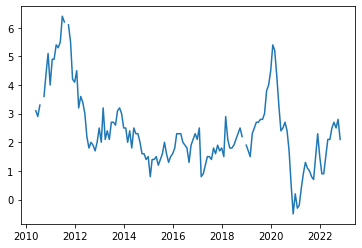

In [6]:
plt.plot(df_new['Close']);

#### Comment:

The time series is characterized by high variability and the absence of a clear long-term trend. No regular, repeating pattern can be observed in the plot, so no clear seasonality can be identified. However, irregular fluctuations are visible, including an increase in values during 2019–2020, followed by a sharp decline. There is also no clear cyclicality, as the observed fluctuations do not repeat at regular time intervals.

### 2. Verification and imputation of missing observations in the time series

In [7]:
    df_new[df_new['Close'].isna()]

,Open,High,Low,Close
Date,,,,
2010-08-31,NaN,NaN,NaN,NaN
2011-08-31,NaN,NaN,NaN,NaN
2018-11-30,NaN,NaN,NaN,NaN


In [8]:
df_new = df_new.interpolate(method='time')

In [9]:
df_new.loc[['2010-08-31','2011-08-31','2018-11-30']]

,Open,High,Low,Close
Date,,,,
2010-08-31,3.452459,3.452459,3.452459,3.452459
2011-08-31,6.149180,6.149180,6.149180,6.149180
2018-11-30,2.052459,2.052459,2.052459,2.052459


#### Comment:

Three missing observations were identified in the dataset and filled using linear interpolation over time based on the values of neighboring observations.

### 3. Splitting the data into training and test sets

In [10]:
train = df_new['Close'].iloc[:-12]
test = df_new['Close'].iloc[-12:]

### 4. Outlier Handling using time series decomposition

#### a. First decomposition

In [11]:
y = train

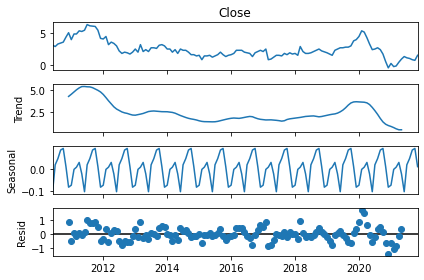

In [12]:
result = seasonal_decompose(y, model='additive')
result.plot()
plt.show()

In [13]:
residuals = result.resid

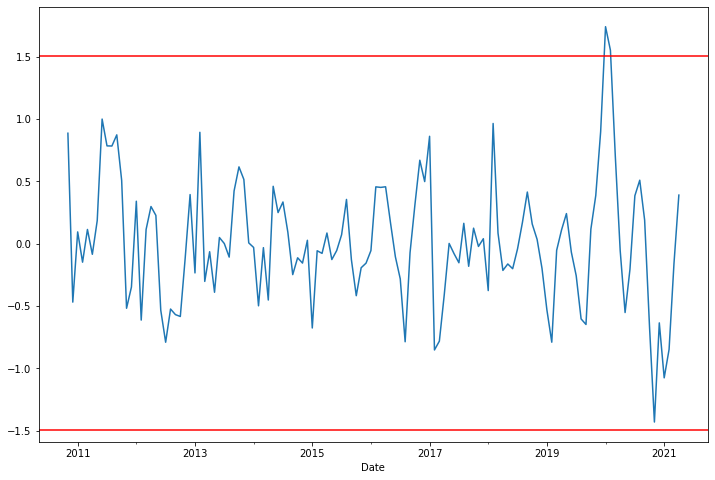

In [14]:
mu, std = norm.fit(residuals.dropna()) 

lower = mu - 3 * std
upper = mu + 3 * std

# 3 sigma
residuals.plot(figsize=(12,8))
plt.axhline(lower, color='r')
plt.axhline(upper, color='r');

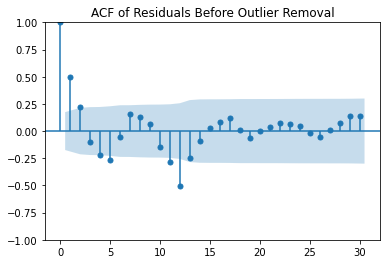

In [15]:
plot_acf(residuals.dropna(), lags=30)
plt.title('ACF of Residuals Before Outlier Removal')
plt.show()

In [16]:
y = pd.DataFrame(y)

In [17]:
y['is_outlier_1'] =  (residuals < lower)| (residuals > upper)

In [18]:

outliers_1 = y['Close'].where(y['is_outlier_1']).dropna()
outliers_1

Date
2020-01-31    5.4
2020-02-29    5.2
Freq: M, Name: Close, dtype: float64

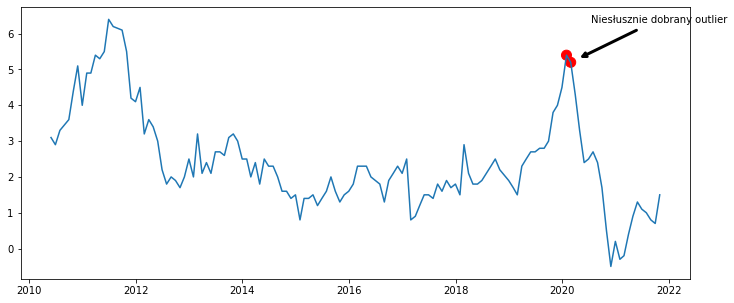

In [19]:
plt.figure(figsize=(12,5))
plt.plot(y['Close'])
plt.scatter(outliers_1.index, outliers_1.values, color='red', s=[100]*outliers_1.shape[0])
plt.annotate('Niesłusznie dobrany outlier',xy=(outliers_1.index[1], outliers_1.values[1]),
    xytext=(20, 40),   
    textcoords='offset points',
    arrowprops=dict(
        arrowstyle='->',
        linewidth=3,
        shrinkA=9,
        shrinkB=10
    )
)
plt.show()

In [20]:
close_without_outliers = y['Close'].where(~y['is_outlier_1'])
rolling_mean = close_without_outliers.rolling(6, min_periods=1).mean()

y['Close_clean_1'] = y['Close'].copy()
y.loc[y['is_outlier_1'], 'Close_clean_1'] = rolling_mean[y['is_outlier_1']]

In [21]:
print("Number of outliers after the first decomposition:", y['is_outlier_1'].sum())

Number of outliers after the first decomposition: 2


#### b. Second decomposition

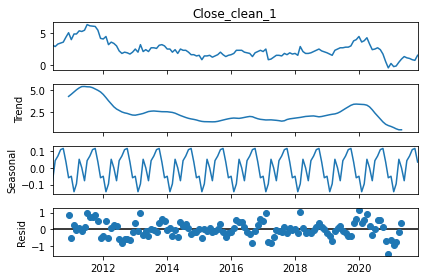

In [22]:
result_2 = seasonal_decompose(y['Close_clean_1'], model='additive')
result_2.plot()
plt.show()

In [23]:
residuals_2 = result_2.resid

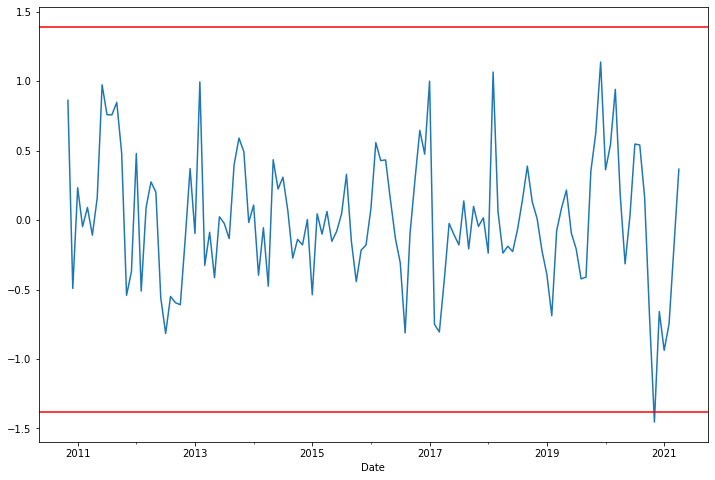

In [24]:
mu, std = norm.fit(residuals_2.dropna()) 

lower_2 = mu - 3 * std
upper_2 = mu + 3 * std

# 3 sigma
residuals_2.plot(figsize=(12,8))
plt.axhline(lower_2, color='r')
plt.axhline(upper_2, color='r');

In [25]:
y['is_outlier_2'] = ((residuals_2 < lower_2) | (residuals_2 > upper_2))

In [26]:
outliers_2 = y['Close_clean_1'].where(y['is_outlier_2']).dropna()

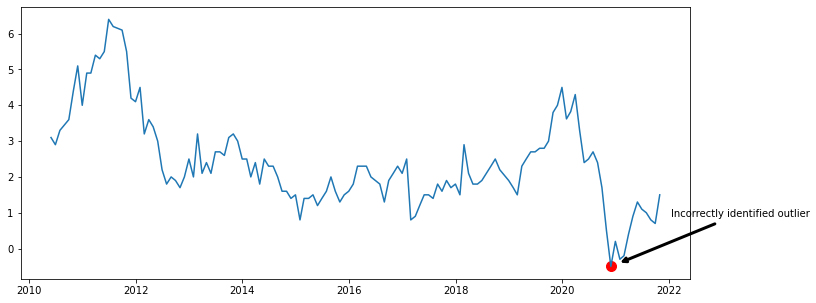

In [27]:
plt.figure(figsize=(12, 5))
plt.plot(y['Close_clean_1'])
plt.scatter( outliers_2.index, outliers_2.values, color='red', s=[100] * outliers_2.shape[0])

plt.annotate('Incorrectly identified outlier', xy=(outliers_2.index[0], outliers_2.values[0]),
    xytext=(60, 50), textcoords='offset points', arrowprops=dict( arrowstyle='->', linewidth=3, shrinkA=9, shrinkB=10))

plt.show()

In [28]:
close_without_outliers_clean = y['Close_clean_1'].where(~y['is_outlier_2'])
rolling_mean_clean = close_without_outliers_clean.rolling(6, min_periods=1).mean()

In [29]:
y['Close_clean_2'] = y['Close_clean_1'].copy()
y.loc[y['is_outlier_2'], 'Close_clean_2'] = rolling_mean_clean[y['is_outlier_2']]

In [30]:
print("Number of outliers after the first decomposition:", y['is_outlier_1'].sum())
print("Number of outliers after the second decomposition:", y['is_outlier_2'].sum())

Number of outliers after the first decomposition: 2
Number of outliers after the second decomposition: 1


### Comments:
After the first decomposition, the 3-sigma rule identified two outliers, which were replaced using a 6-period rolling mean. After the second decomposition, one additional outlier was identified and replaced using the same method. Following the third decomposition, no further outliers were detected, indicating that the iterative outlier removal process was completed.

### 5. ACF and PACF Analysis

In [31]:
acf(train)

array([ 1.        ,  0.92822113,  0.86473519,  0.78388641,  0.71057512,
        0.63333486,  0.56719922,  0.49515519,  0.40424249,  0.31192983,
        0.21188913,  0.12432885,  0.029992  ,  0.00770318, -0.0108162 ,
       -0.01801765, -0.02727262, -0.02997843, -0.04489985, -0.04472218,
       -0.02169195,  0.00216736])

In [33]:
train_clean_1 = y['Close_clean_1']
train_clean_2 = y['Close_clean_2']

Text(0.5, 1.0, 'PACF - After Second Decomposition')

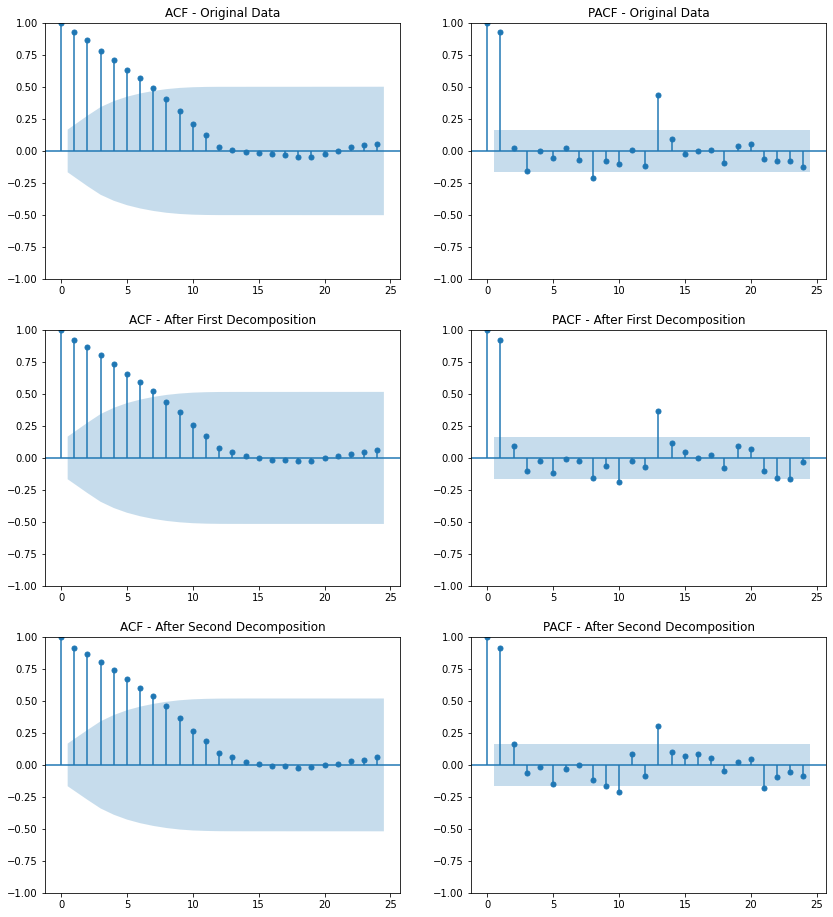

In [35]:
fig, axes = plt.subplots(3, 2, figsize=(14, 16))

# Original
plot_acf(train, lags=24, ax=axes[0, 0])
axes[0, 0].set_title("ACF - Original Data")

plot_pacf(train, lags=24, ax=axes[0, 1])
axes[0, 1].set_title("PACF - Original Data")

# First decomposition
plot_acf(train_clean_1, lags=24, ax=axes[1, 0])
axes[1, 0].set_title("ACF - After First Decomposition")

plot_pacf(train_clean_1, lags=24, ax=axes[1, 1])
axes[1, 1].set_title("PACF - After First Decomposition")

# Second decomposition
plot_acf(train_clean_2, lags=24, ax=axes[2, 0])
axes[2, 0].set_title("ACF - After Second Decomposition")

plot_pacf(train_clean_2, lags=24, ax=axes[2, 1])
axes[2, 1].set_title("PACF - After Second Decomposition")


### Comment:

The ACF and PACF patterns remain similar after the subsequent decomposition stages, indicating that outlier removal had only a limited impact on the autocorrelation structure.

### 6. AutoARIMA Model

In [36]:
def fit_and_forecast(model, train, test):

    model.fit(train)

    y_pred = model.predict(fh=test.index)

    plt.figure(figsize=(15, 6))

    plt.plot(train.index, train, label="Train")
    plt.plot(test.index, test, label="Actual test")
    plt.plot(y_pred.index, y_pred, label="Forecast")

    plt.axvline(
        test.index[0],
        linestyle="--",
        label="Start test"
    )

    plt.title("Prognoza na zbiorze testowym")
    plt.xlabel("Date")
    plt.ylabel("Monthly")
    plt.legend()

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return y_pred

C:\Users\User\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\User\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\User\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\User\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\User\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\User\a

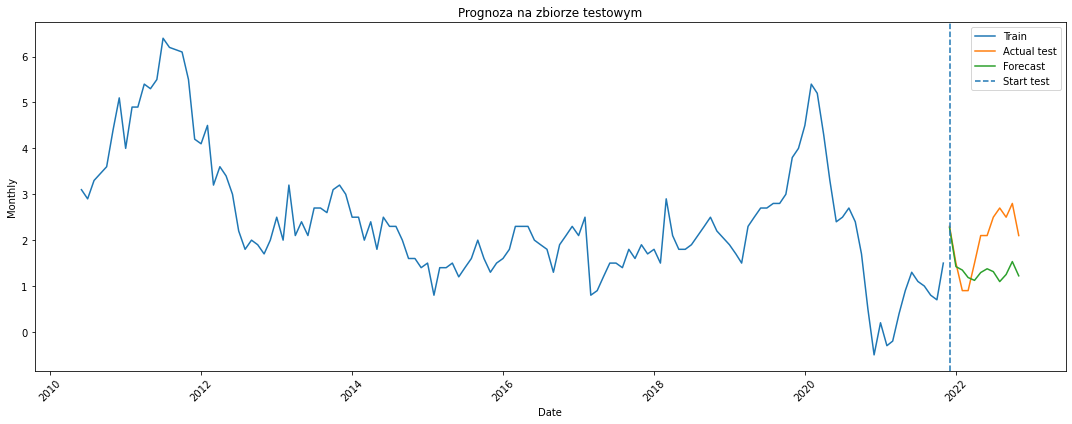

In [37]:
auto_arima_model = AutoARIMA(start_p=1, d=None, start_q=1, max_p=3, max_d=2, max_q=6, start_P=0,
          D=None, start_Q=0, max_P=2, max_D=1, max_Q=2, max_order=8, sp=12,
          seasonal=True, stationary=False)

y_pred_arima_auto_org = fit_and_forecast(auto_arima_model, train, test)

C:\Users\User\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\User\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\User\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\User\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\User\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\User\a

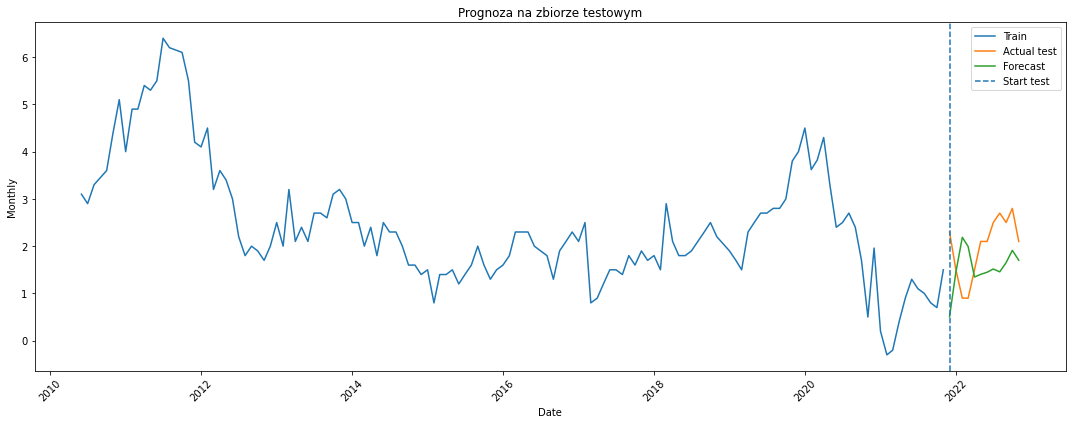

In [38]:
auto_arima_model_cl = AutoARIMA(start_p=1, d=None, start_q=1, max_p=3, max_d=2, max_q=6, start_P=0,
          D=None, start_Q=0, max_P=2, max_D=1, max_Q=2, max_order=8, sp=12,
          seasonal=True, stationary=False)

y_pred_arima_auto_cle = fit_and_forecast(auto_arima_model_cl, train_clean_2, test)

### 7. Forecast Evaluation

In [39]:
mae_arima_original = mean_absolute_error(test, y_pred_arima_auto_org)
mae_arima_clean = mean_absolute_error(test, y_pred_arima_auto_cle)
mape_arima_original = mean_absolute_percentage_error(test,y_pred_arima_auto_org)
mape_arima_clean = mean_absolute_percentage_error(test, y_pred_arima_auto_cle)

arima_results = pd.DataFrame({"Model": ["AutoARIMA - Original","AutoARIMA - Cleaned"],
    "MAE": [mae_arima_original, mae_arima_clean],
    "MAPE": [mape_arima_original,mape_arima_clean]
})

arima_results

,Model,MAE,MAPE
0,AutoARIMA - Original,0.743547,0.357809
1,AutoARIMA - Cleaned,0.840138,0.491610


### Comment:

The AutoARIMA model trained on the original data achieved better performance, with a lower MAE (0.744) and MAPE (35.78%), compared with the model trained on the cleaned data, which obtained an MAE of 0.840 and a MAPE of 49.16%. Both models were evaluated on the same test set. These results indicate that, for this dataset, removing the detected outliers did not improve the forecasting accuracy of the AutoARIMA model.

### 8. Holt-Winters Model

In [40]:
train[train < 0] = 0.001

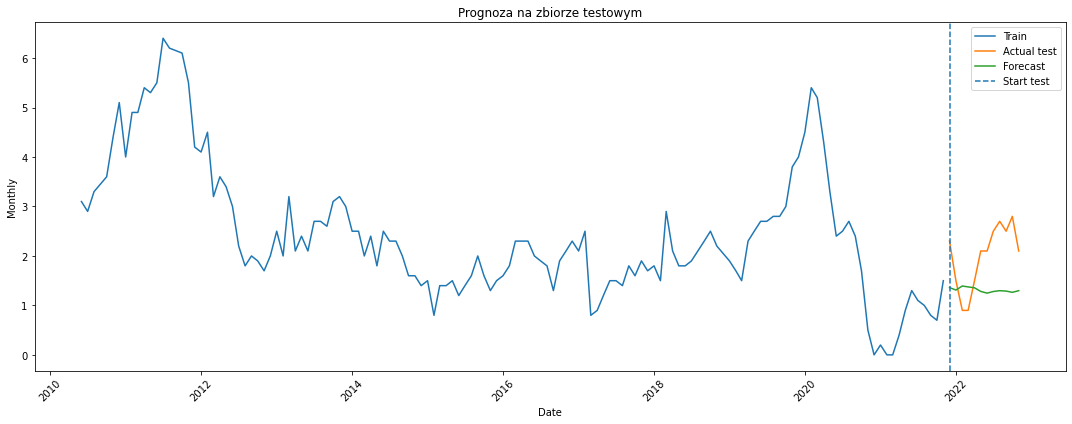

In [41]:
hw_model_add = ExponentialSmoothing(trend = 'add', seasonal = 'additive', sp =12)
y_pred_hw_add = fit_and_forecast(hw_model_add,train,test)

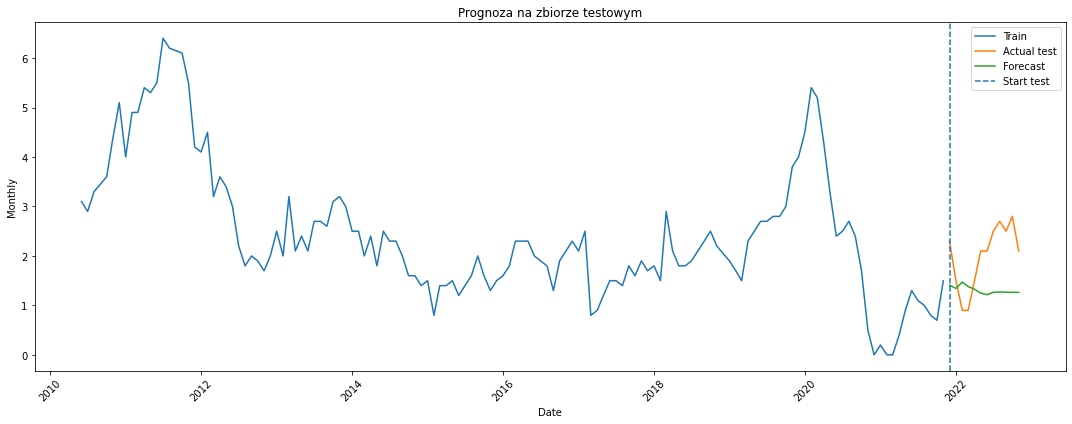

In [42]:
hw_model_multi = ExponentialSmoothing(trend='add', seasonal='multiplicative', sp=12) 
y_pred_hw_multi= fit_and_forecast(hw_model_multi,train,test)

In [49]:
mae_hw_add = mean_absolute_error(test, y_pred_hw_add)
rmse_hw_add = np.sqrt(mean_squared_error(test, y_pred_hw_add))
mape_hw_add = np.mean(np.abs((test - y_pred_hw_add)  / test )) * 100

mae_hw_multi = mean_absolute_error(test, y_pred_hw_multi)
rmse_hw_multi = np.sqrt(mean_squared_error(test, y_pred_hw_multi))
mape_hw_multi = np.mean(np.abs((test - y_pred_hw_multi)  / test )) * 100


results_Holt_Winters = pd.DataFrame({
        "Metrics": ["MAE", "RMSE", "MAPE"],
        "Holt-Winters_add": [mae_hw_add, rmse_hw_add, mape_hw_add],
        "Holt-Winters_multi": [mae_hw_multi, rmse_hw_multi, mape_hw_multi]
    })
results_Holt_Winters

,Metrics,Holt-Winters_add,Holt-Winters_multi
0,MAE,0.839514,0.856445
1,RMSE,0.944738,0.959886
2,MAPE,40.997954,42.229741


In [44]:
train_clean_2 = train_clean_2.copy()
train_clean_2[train_clean_2 < 0] = 0.001

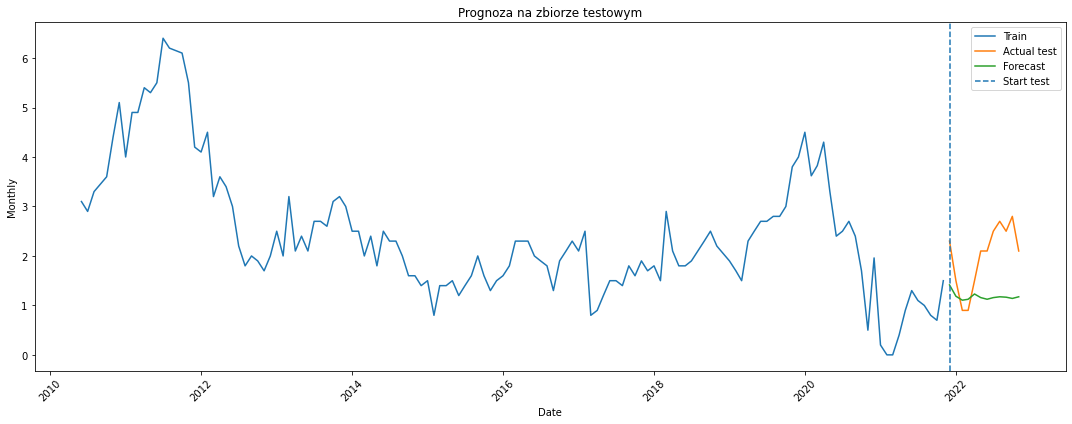

In [45]:
hw_model_add_2 = ExponentialSmoothing(trend = 'add', seasonal = 'additive', sp =12)
y_pred_hw_add_2 = fit_and_forecast(hw_model_add_2,train_clean_2,test)

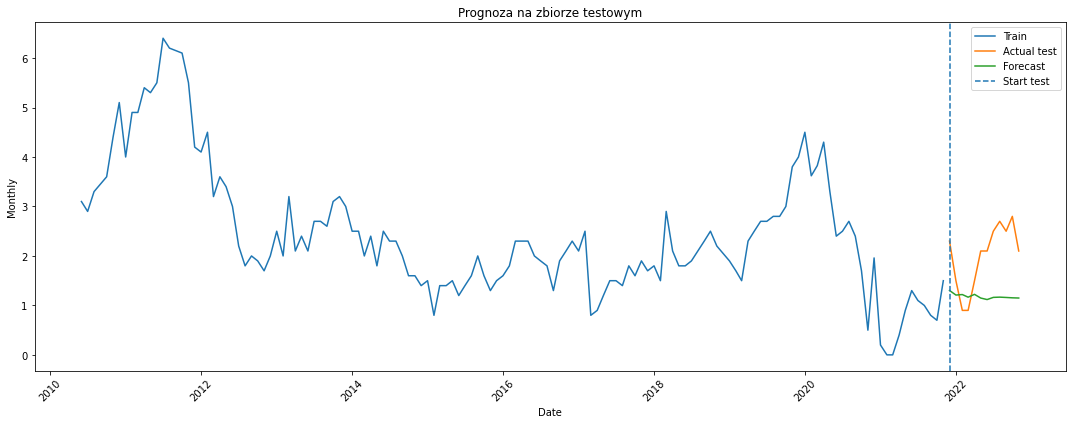

In [46]:
hw_model_multi_2 = ExponentialSmoothing(trend='add', seasonal='multiplicative', sp=12) 
y_pred_hw_multi_2 = fit_and_forecast(hw_model_multi_2,train_clean_2,test)

In [48]:
mae_hw_add_clean = mean_absolute_error(test, y_pred_hw_add_2)
rmse_hw_add_clean = np.sqrt(mean_squared_error(test, y_pred_hw_add_2))
mape_hw_add_clean = np.mean(np.abs((test - y_pred_hw_add_2)  / test )) * 100

mae_hw_multi_clean = mean_absolute_error(test, y_pred_hw_multi_2)
rmse_hw_multi_clean = np.sqrt(mean_squared_error(test, y_pred_hw_multi_2))
mape_hw_multi_clean = np.mean(np.abs((test - y_pred_hw_multi_2)  / test )) * 100


results_Holt_Winters_clean = pd.DataFrame({
        "Metrics": ["MAE", "RMSE", "MAPE"],
        "Holt-Winters_add": [mae_hw_add_clean, rmse_hw_add_clean, mape_hw_add_clean],
        "Holt-Winters_multi": [mae_hw_multi_clean, rmse_hw_multi_clean, mape_hw_multi_clean]
    })
results_Holt_Winters_clean

,Metrics,Holt-Winters_add,Holt-Winters_multi
0,MAE,0.883320,0.907221
1,RMSE,1.016397,1.030212
2,MAPE,40.270680,42.176609


### Comment:

The results show that the Holt-Winters additive model performs slightly better than the multiplicative model for all three evaluation metrics, both on the original dataset and after removing outliers.
Overall, the additive model has lower errors in all cases. Removing outliers does not improve MAE or RMSE, but it slightly reduces MAPE.